# NSD / Algonauts 2023 → COCO captions

Notebook completo para construir automáticamente:

**imagen Algonauts → NSD ID → COCO ID → captions humanos de COCO**

La salida final contiene, por muestra:

- sujeto;
- split (`train` / `test`);
- índice de condición Algonauts;
- índice 0-based alineable con fMRI;
- nombre y ruta de imagen;
- `nsd_id`;
- `coco_id`;
- `coco_split`;
- captions COCO;
- categorias COCO;
- prompt basado en categorias COCO;
- caption fijo, caption muestreado y caption permutado para controles.

## Estructura esperada

```text
Datasets/
└── NSD_Algonauts_2023/
    ├── train_data/
    │   └── subjXX/...
    └── test_data/
        └── subjXX/...

Documents/
└── Datasets/
    └── NSD_Algonauts_2023/
        └── auxiliar/
            ├── captions_train2017.json
            ├── captions_val2017.json
            ├── nsd_stim_info_merged.pkl
            └── nsd_stim_info_merged.csv
```

Según el README de Algonauts, un nombre como:

```text
train-0001_nsd-00013.png
```

contiene:

- `train-0001`: orden de condición, alineado con la primera dimensión del fMRI;
- `nsd-00013`: ID 0-based dentro de las 73 000 imágenes NSD.

El notebook no asume a ciegas cómo está indexada la columna NSD del CSV/PKL: lo comprueba automáticamente.

## 1. Dependencias

Si falta alguna librería:

```bash
pip install pandas numpy matplotlib pillow tqdm
```

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

SEED = 42
print("Imports OK")

Imports OK


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuración de rutas

`WORKSPACE_ROOT` debe ser el directorio que contiene a la vez `Datasets/` y `Documents/`.

El código intenta detectarlo automáticamente desde el directorio actual. Si no coincide con tu proyecto, define manualmente una ruta absoluta.

In [2]:
DATASET_ROOT = Path(r"C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023")

TRAIN_ROOT = DATASET_ROOT / "train_data"
TEST_ROOT  = DATASET_ROOT / "test_data"
AUX_DIR    = DATASET_ROOT / "auxiliar"

CAPTIONS_TRAIN_JSON = AUX_DIR / "captions_train2017.json"
CAPTIONS_VAL_JSON   = AUX_DIR / "captions_val2017.json"
INSTANCES_TRAIN_JSON = AUX_DIR / "instances_train2017.json"
INSTANCES_VAL_JSON   = AUX_DIR / "instances_val2017.json"

NSD_METADATA_CSV = AUX_DIR / "nsd_stim_info_merged.csv"
NSD_METADATA_PKL = AUX_DIR / "nsd_stim_info_merged.pkl"

OUTPUT_DIR = AUX_DIR / "generated_captions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT   :", DATASET_ROOT)
print("TRAIN_ROOT     :", TRAIN_ROOT)
print("TEST_ROOT      :", TEST_ROOT)
print("AUX_DIR        :", AUX_DIR)
print("OUTPUT_DIR     :", OUTPUT_DIR)

DATASET_ROOT   : C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023
TRAIN_ROOT     : C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data
TEST_ROOT      : C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data
AUX_DIR        : C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar
OUTPUT_DIR     : C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions


In [3]:
required_files = {
    "captions_train2017.json": CAPTIONS_TRAIN_JSON,
    "captions_val2017.json": CAPTIONS_VAL_JSON,
    "instances_train2017.json": INSTANCES_TRAIN_JSON,
    "instances_val2017.json": INSTANCES_VAL_JSON,
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encuentra {name}: {path}")

if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f"No existe TRAIN_ROOT: {TRAIN_ROOT}")

if not TEST_ROOT.exists():
    warnings.warn(f"No existe TEST_ROOT: {TEST_ROOT}. Se podrá procesar solo train.")

if not NSD_METADATA_CSV.exists() and not NSD_METADATA_PKL.exists():
    raise FileNotFoundError(
        "No se encuentra ni nsd_stim_info_merged.csv ni nsd_stim_info_merged.pkl"
    )

print("✓ Rutas verificadas")

✓ Rutas verificadas


## 3. Cargar `nsd_stim_info_merged`

Se usa primero el CSV por ser más transparente para depuración. Si no existe, se utiliza el PKL.

In [4]:
def load_nsd_metadata(csv_path: Path, pkl_path: Path, prefer="csv") -> pd.DataFrame:
    prefer = prefer.lower()

    if prefer not in {"csv", "pkl"}:
        raise ValueError("prefer debe ser 'csv' o 'pkl'")

    order = [prefer, "pkl" if prefer == "csv" else "csv"]

    for fmt in order:
        if fmt == "csv" and csv_path.exists():
            print("Cargando:", csv_path)
            return pd.read_csv(csv_path)

        if fmt == "pkl" and pkl_path.exists():
            print("Cargando:", pkl_path)
            obj = pd.read_pickle(pkl_path)

            if isinstance(obj, pd.DataFrame):
                return obj.copy()

            if isinstance(obj, dict):
                return pd.DataFrame(obj)

            raise TypeError(f"PKL no reconocido: {type(obj)}")

    raise FileNotFoundError("No se pudo cargar el metadata NSD.")


nsd_meta = load_nsd_metadata(
    NSD_METADATA_CSV,
    NSD_METADATA_PKL,
    prefer="csv",
)

print("Shape:", nsd_meta.shape)
print("Columnas:")
print(nsd_meta.columns.tolist())

display(nsd_meta.head())

Cargando: C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\nsd_stim_info_merged.csv
Shape: (73000, 41)
Columnas:
['Unnamed: 0', 'cocoId', 'cocoSplit', 'cropBox', 'loss', 'nsdId', 'flagged', 'BOLD5000', 'shared1000', 'subject1', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6', 'subject7', 'subject8', 'subject1_rep0', 'subject1_rep1', 'subject1_rep2', 'subject2_rep0', 'subject2_rep1', 'subject2_rep2', 'subject3_rep0', 'subject3_rep1', 'subject3_rep2', 'subject4_rep0', 'subject4_rep1', 'subject4_rep2', 'subject5_rep0', 'subject5_rep1', 'subject5_rep2', 'subject6_rep0', 'subject6_rep1', 'subject6_rep2', 'subject7_rep0', 'subject7_rep1', 'subject7_rep2', 'subject8_rep0', 'subject8_rep1', 'subject8_rep2']


,Unnamed: 0,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,subject3,subject4,subject5,subject6,subject7,subject8,subject1_rep0,subject1_rep1,subject1_rep2,subject2_rep0,subject2_rep1,subject2_rep2,subject3_rep0,subject3_rep1,subject3_rep2,subject4_rep0,subject4_rep1,subject4_rep2,subject5_rep0,subject5_rep1,subject5_rep2,subject6_rep0,subject6_rep1,subject6_rep2,subject7_rep0,subject7_rep1,subject7_rep2,subject8_rep0,subject8_rep1,subject8_rep2
0,0,532481,val2017,"(0, 0, 0.1671875, 0.1671875)",0.100000,0,False,False,False,0,0,1,0,0,0,0,0,0,0,0,0,0,0,13792,14918,28011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,245764,val2017,"(0, 0, 0.125, 0.125)",0.000000,1,False,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13985,14176,28603,0,0,0
2,2,385029,val2017,"(0, 0, 0.125, 0.125)",0.000000,2,False,False,False,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1042,22634,26547,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,311303,val2017,"(0, 0, 0.16640625, 0.16640625)",0.125000,3,False,False,False,0,0,1,0,0,0,0,0,0,0,0,0,0,0,18180,18551,18638,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,393226,val2017,"(0, 0, 0.125, 0.125)",0.133333,4,False,False,False,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13720,22861,23023,0,0,0,0,0,0


## 4. Detectar columnas importantes

Necesitamos:

- ID NSD, si existe como columna explícita;
- `cocoId`;
- `cocoSplit`.

La detección tolera pequeñas variaciones en nombres.

In [5]:
def canonical_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def find_column(df, candidates, required=True):
    normalized = {
        canonical_name(col): col
        for col in df.columns
    }

    for candidate in candidates:
        key = canonical_name(candidate)

        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"No encuentro {candidates}. "
            f"Columnas disponibles: {df.columns.tolist()}"
        )

    return None


NSD_ID_COL = find_column(
    nsd_meta,
    ["nsdId", "nsd_id", "nsdid", "nsd"],
    required=False,
)

COCO_ID_COL = find_column(
    nsd_meta,
    ["cocoId", "coco_id", "cocoid"],
)

COCO_SPLIT_COL = find_column(
    nsd_meta,
    ["cocoSplit", "coco_split", "cocosplit", "split"],
)

print("NSD_ID_COL    :", NSD_ID_COL)
print("COCO_ID_COL   :", COCO_ID_COL)
print("COCO_SPLIT_COL:", COCO_SPLIT_COL)

display(nsd_meta[COCO_SPLIT_COL].value_counts(dropna=False))

NSD_ID_COL    : nsdId
COCO_ID_COL   : cocoId
COCO_SPLIT_COL: cocoSplit


cocoSplit
train2017    70051
val2017       2949
Name: count, dtype: int64

## 5. Cargar captions COCO

Cada JSON se transforma en:

```python
coco_id -> [caption_1, caption_2, ...]
```

In [6]:
def load_coco_caption_index(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if "annotations" not in data:
        raise KeyError(f"{json_path.name} no tiene la clave 'annotations'")

    index = defaultdict(list)

    for ann in data["annotations"]:
        image_id = int(ann["image_id"])
        caption = str(ann["caption"]).strip()
        index[image_id].append(caption)

    return dict(index)


def load_coco_category_index(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if "annotations" not in data:
        raise KeyError(f"{json_path.name} no tiene la clave 'annotations'")

    if "categories" not in data:
        raise KeyError(f"{json_path.name} no tiene la clave 'categories'")

    category_id_to_name = {
        int(category["id"]): str(category["name"]).strip()
        for category in data["categories"]
    }

    index = defaultdict(list)
    seen_by_image = defaultdict(set)

    for ann in data["annotations"]:
        image_id = int(ann["image_id"])
        category_id = int(ann["category_id"])

        if category_id not in category_id_to_name:
            raise KeyError(f"category_id ausente en categories: {category_id}")

        category_name = category_id_to_name[category_id]

        if category_name not in seen_by_image[image_id]:
            index[image_id].append(category_name)
            seen_by_image[image_id].add(category_name)

    return dict(index)


def format_prompt_categories(categories: list[str]) -> str | None:
    clean_categories = [
        str(category).strip()
        for category in categories
        if str(category).strip()
    ]

    if not clean_categories:
        return None

    if len(clean_categories) == 1:
        return f"a {clean_categories[0]}"

    if len(clean_categories) == 2:
        return f"a {clean_categories[0]} and {clean_categories[1]}"

    return f"a {', '.join(clean_categories[:-1])} and {clean_categories[-1]}"


train_caption_index = load_coco_caption_index(CAPTIONS_TRAIN_JSON)
val_caption_index   = load_coco_caption_index(CAPTIONS_VAL_JSON)
train_category_index = load_coco_category_index(INSTANCES_TRAIN_JSON)
val_category_index   = load_coco_category_index(INSTANCES_VAL_JSON)

print("COCO train con captions:", len(train_caption_index))
print("COCO val con captions  :", len(val_caption_index))
print("COCO train con categories:", len(train_category_index))
print("COCO val con categories  :", len(val_category_index))

train_counts = pd.Series([len(x) for x in train_caption_index.values()])
val_counts   = pd.Series([len(x) for x in val_caption_index.values()])
train_category_counts = pd.Series([len(x) for x in train_category_index.values()])
val_category_counts   = pd.Series([len(x) for x in val_category_index.values()])

print("\nDistribución nº captions - train")
display(train_counts.value_counts().sort_index())

print("\nDistribución nº captions - val")
display(val_counts.value_counts().sort_index())

print("\nDistribucion numero categories - train")
display(train_category_counts.value_counts().sort_index())

print("\nDistribucion numero categories - val")
display(val_category_counts.value_counts().sort_index())

COCO train con captions: 118287
COCO val con captions  : 5000
COCO train con categories: 117266
COCO val con categories  : 4952

Distribución nº captions - train


5    117972
6       312
7         3
Name: count, dtype: int64


Distribución nº captions - val


5    4987
6      12
7       1
Name: count, dtype: int64


Distribucion numero categories - train


1     24186
2     35858
3     24169
4     13973
5      8283
6      4783
7      2790
8      1529
9       846
10      439
11      224
12      111
13       47
14       16
15        9
16        2
18        1
Name: count, dtype: int64


Distribucion numero categories - val


1     1025
2     1522
3      980
4      591
5      344
6      211
7      120
8       78
9       38
10      22
11      11
12       6
13       3
14       1
Name: count, dtype: int64

## 6. Descubrir imágenes Algonauts

Se buscan recursivamente todos los PNG con el patrón oficial:

```text
train-XXXX_nsd-XXXXX.png
test-XXXX_nsd-XXXXX.png
```

No importa si dentro de cada sujeto tienes una carpeta adicional como `training_split/training_images`.

In [7]:
SUBJECT_RE = re.compile(r"subj\d{2}", re.IGNORECASE)
FILENAME_RE = re.compile(
    r"^(train|test)-(\d+)_nsd-(\d+)\.png$",
    re.IGNORECASE,
)


def infer_subject(path: Path):
    for part in path.parts:
        if SUBJECT_RE.fullmatch(part):
            return part.lower()
    return None


def discover_algonauts_images(root: Path, split: str) -> pd.DataFrame:
    split = split.lower()

    if split not in {"train", "test"}:
        raise ValueError("split debe ser train o test")

    if not root.exists():
        return pd.DataFrame()

    rows = []

    for image_path in sorted(root.rglob("*.png")):
        match = FILENAME_RE.match(image_path.name)

        if match is None:
            continue

        file_split = match.group(1).lower()

        if file_split != split:
            continue

        challenge_idx = int(match.group(2))
        nsd_id = int(match.group(3))
        subject = infer_subject(image_path)

        if subject is None:
            warnings.warn(f"No se detecta sujeto en: {image_path}")
            continue

        rows.append({
            "split": split,
            "subject": subject,
            "challenge_idx_1based": challenge_idx,
            "row_idx_0based": challenge_idx - 1,
            "nsd_id": nsd_id,
            "filename": image_path.name,
            "image_path": str(image_path.resolve()),
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        df = (
            df
            .sort_values(["subject", "challenge_idx_1based"])
            .reset_index(drop=True)
        )

    return df


train_images = discover_algonauts_images(TRAIN_ROOT, "train")
test_images  = discover_algonauts_images(TEST_ROOT, "test")

print("Train:", train_images.shape)
print("Test :", test_images.shape)

if len(train_images):
    display(train_images.head())

if len(test_images):
    display(test_images.head())

Train: (75086, 7)
Test : (2012, 7)


,split,subject,challenge_idx_1based,row_idx_0based,nsd_id,filename,image_path
0,train,subj01,1,0,13,train-0001_nsd-00013.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0001_nsd...
1,train,subj01,2,1,27,train-0002_nsd-00027.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0002_nsd...
2,train,subj01,3,2,71,train-0003_nsd-00071.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0003_nsd...
3,train,subj01,4,3,85,train-0004_nsd-00085.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0004_nsd...
4,train,subj01,5,4,88,train-0005_nsd-00088.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0005_nsd...


,split,subject,challenge_idx_1based,row_idx_0based,nsd_id,filename,image_path
0,test,subj01,1,0,845,test-0001_nsd-00845.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data\subj01\test_split\test_images\test-0001_nsd-00845.png
1,test,subj01,2,1,946,test-0002_nsd-00946.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data\subj01\test_split\test_images\test-0002_nsd-00946.png
2,test,subj01,3,2,1517,test-0003_nsd-01517.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data\subj01\test_split\test_images\test-0003_nsd-01517.png
3,test,subj01,4,3,2655,test-0004_nsd-02655.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data\subj01\test_split\test_images\test-0004_nsd-02655.png
4,test,subj01,5,4,2713,test-0005_nsd-02713.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\test_data\subj01\test_split\test_images\test-0005_nsd-02713.png


## 7. Validar el orden Algonauts

Para cada sujeto comprobamos que:

- empieza en 1;
- no hay duplicados;
- no existen huecos.

Es una validación crítica para no desalinear fMRI e imagen.

In [8]:
def validate_image_order(df: pd.DataFrame, name: str):
    if df.empty:
        print(f"{name}: vacío")
        return

    errors = []

    for subject, group in df.groupby("subject"):
        idx = group["challenge_idx_1based"].to_numpy()

        if len(np.unique(idx)) != len(idx):
            errors.append(f"{subject}: índices duplicados")

        expected = np.arange(1, len(group) + 1)

        if not np.array_equal(idx, expected):
            errors.append(
                f"{subject}: secuencia no contigua; "
                f"inicio={idx[:5]}, final={idx[-5:]}"
            )

    if errors:
        raise ValueError("\n".join(errors))

    print(f"✓ {name}: índices correctos")


validate_image_order(train_images, "TRAIN")
validate_image_order(test_images, "TEST")

✓ TRAIN: índices correctos
✓ TEST: índices correctos


## 8. Resolver 0-based / 1-based en el metadata NSD

El ID `nsd-XXXXX` del PNG es nuestra referencia 0-based.

Si el metadata tiene una columna NSD explícita, se detecta si:

- empieza en 0 → se usa directamente;
- empieza en 1 → se resta 1.

Si no existe una columna fiable, se usa la posición `iloc[nsd_id]`.

In [9]:
observed_nsd_ids = pd.concat(
    [
        train_images.get("nsd_id", pd.Series(dtype=int)),
        test_images.get("nsd_id", pd.Series(dtype=int)),
    ],
    ignore_index=True,
).dropna().astype(int).unique()

if len(observed_nsd_ids) == 0:
    raise RuntimeError("No se encontraron NSD IDs.")


def resolve_nsd_lookup_mode(meta, nsd_col, observed_ids):
    observed_ids = np.asarray(observed_ids, dtype=int)

    if nsd_col is not None:
        values = (
            pd.to_numeric(meta[nsd_col], errors="coerce")
            .dropna()
            .astype(int)
        )

        if not values.duplicated().any():
            vmin = int(values.min())
            vmax = int(values.max())

            print(f"Rango columna {nsd_col}: {vmin} ... {vmax}")

            if vmin == 0:
                return "explicit_0based"

            if vmin == 1 and vmax >= len(meta):
                return "explicit_1based"

            values_set = set(values.tolist())

            direct_hits = np.mean(
                [int(i) in values_set for i in observed_ids]
            )
            plus1_hits = np.mean(
                [int(i) + 1 in values_set for i in observed_ids]
            )

            print(
                f"Coincidencia directa={direct_hits:.4f}, "
                f"coincidencia +1={plus1_hits:.4f}"
            )

            if direct_hits > plus1_hits:
                return "explicit_0based"

            if plus1_hits > direct_hits:
                return "explicit_1based"

    if observed_ids.max() < len(meta):
        return "row_position_0based"

    raise RuntimeError(
        "No se pudo determinar de forma segura cómo indexar NSD."
    )


NSD_LOOKUP_MODE = resolve_nsd_lookup_mode(
    nsd_meta,
    NSD_ID_COL,
    observed_nsd_ids,
)

print("Modo seleccionado:", NSD_LOOKUP_MODE)

Rango columna nsdId: 0 ... 72999
Modo seleccionado: explicit_0based


In [10]:
if NSD_LOOKUP_MODE == "explicit_0based":
    nsd_lookup = nsd_meta.copy()
    nsd_lookup["_lookup_nsd_id"] = (
        pd.to_numeric(nsd_lookup[NSD_ID_COL], errors="raise")
        .astype(int)
    )

elif NSD_LOOKUP_MODE == "explicit_1based":
    nsd_lookup = nsd_meta.copy()
    nsd_lookup["_lookup_nsd_id"] = (
        pd.to_numeric(nsd_lookup[NSD_ID_COL], errors="raise")
        .astype(int)
        - 1
    )

else:
    nsd_lookup = nsd_meta.reset_index(drop=True).copy()
    nsd_lookup["_lookup_nsd_id"] = np.arange(
        len(nsd_lookup),
        dtype=int,
    )

if nsd_lookup["_lookup_nsd_id"].duplicated().any():
    raise ValueError("El lookup NSD contiene IDs duplicados.")

nsd_lookup = nsd_lookup.set_index("_lookup_nsd_id", drop=False)


def get_nsd_row(nsd_id: int) -> pd.Series:
    nsd_id = int(nsd_id)

    if nsd_id not in nsd_lookup.index:
        raise KeyError(f"NSD ID ausente: {nsd_id}")

    return nsd_lookup.loc[nsd_id]


example_id = int(observed_nsd_ids[0])
example = get_nsd_row(example_id)

print("Ejemplo NSD:", example_id)
print("COCO ID    :", example[COCO_ID_COL])
print("COCO split :", example[COCO_SPLIT_COL])

Ejemplo NSD: 13
COCO ID    : 24610
COCO split : val2017


## 9. Normalizar el split COCO

In [11]:
def normalize_coco_split(value) -> str:
    s = canonical_name(value)

    if "train" in s:
        return "train2017"

    if "val" in s or "valid" in s:
        return "val2017"

    raise ValueError(f"COCO split no reconocido: {value!r}")


for value in nsd_meta[COCO_SPLIT_COL].dropna().unique():
    try:
        print(repr(value), "->", normalize_coco_split(value))
    except ValueError as exc:
        print("AVISO:", exc)

'val2017' -> val2017
'train2017' -> train2017


## 10. Pipeline central: NSD → COCO → caption

In [12]:
def captions_for_coco(coco_id: int, coco_split: str):
    coco_id = int(coco_id)
    split = normalize_coco_split(coco_split)

    if split == "train2017":
        return train_caption_index.get(coco_id, [])

    if split == "val2017":
        return val_caption_index.get(coco_id, [])

    raise ValueError(split)


def categories_for_coco(coco_id: int, coco_split: str):
    coco_id = int(coco_id)
    split = normalize_coco_split(coco_split)

    if split == "train2017":
        return train_category_index.get(coco_id, [])

    if split == "val2017":
        return val_category_index.get(coco_id, [])

    raise ValueError(split)


def attach_captions(images_df: pd.DataFrame) -> pd.DataFrame:
    if images_df.empty:
        return images_df.copy()

    rows = []

    for item in tqdm(
        images_df.itertuples(index=False),
        total=len(images_df),
        desc="NSD → COCO",
    ):
        meta_row = get_nsd_row(item.nsd_id)

        coco_id_raw = meta_row[COCO_ID_COL]
        coco_split_raw = meta_row[COCO_SPLIT_COL]

        if pd.isna(coco_id_raw):
            raise ValueError(f"NSD {item.nsd_id}: cocoId es NaN")

        if pd.isna(coco_split_raw):
            raise ValueError(f"NSD {item.nsd_id}: cocoSplit es NaN")

        coco_id = int(coco_id_raw)
        coco_split = normalize_coco_split(coco_split_raw)
        captions = captions_for_coco(coco_id, coco_split)
        categories = categories_for_coco(coco_id, coco_split)

        row = item._asdict()

        row.update({
            "coco_id": coco_id,
            "coco_split": coco_split,
            "num_captions": len(captions),
            "captions": captions,
            "categories": categories,
            "prompt_categories": format_prompt_categories(categories),
            "primary_caption": captions[0] if captions else None,
        })

        for i in range(5):
            row[f"caption_{i+1}"] = (
                captions[i]
                if i < len(captions)
                else None
            )

        rows.append(row)

    return pd.DataFrame(rows)


train_table = attach_captions(train_images)
test_table  = attach_captions(test_images)

print("Train table:", train_table.shape)
print("Test table :", test_table.shape)

if len(train_table):
    display(train_table.head())

NSD → COCO: 100%|██████████| 2012/2012 [00:00<00:00, 20845.12it/s]

Train table: (75086, 19)
Test table : (2012, 19)


,split,subject,challenge_idx_1based,row_idx_0based,nsd_id,filename,image_path,coco_id,coco_split,num_captions,captions,categories,prompt_categories,primary_caption,caption_1,caption_2,caption_3,caption_4,caption_5
0,train,subj01,1,0,13,train-0001_nsd-00013.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0001_nsd...,24610,val2017,5,"[A disorderly living area is free from decorative elements., A small living space with a couch, desk, chair, and boo...","[chair, couch, laptop, book, backpack, bottle]","a chair, couch, laptop, book, backpack and bottle",A disorderly living area is free from decorative elements.,A disorderly living area is free from decorative elements.,"A small living space with a couch, desk, chair, and bookcase.",There is a laptop computer in a room with a couch and a bookcase.,A simple room with minimal decor and furniture.,A small room with a computer and bookcase.
1,train,subj01,2,1,27,train-0002_nsd-00027.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0002_nsd...,254016,val2017,5,"[A row of doughnuts being passed through a fryer., a conveyor belt with a lot of donuts getting fried up, A fryer ha...","[bowl, donut, person]","a bowl, donut and person",A row of doughnuts being passed through a fryer.,A row of doughnuts being passed through a fryer.,a conveyor belt with a lot of donuts getting fried up,A fryer has rows and rows of doughnuts on an assembly line.,a doughnut factory making doughnuts in oil,A machine that holds a lot of donuts and cooks them.
2,train,subj01,3,2,71,train-0003_nsd-00071.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0003_nsd...,286908,val2017,5,"[Various dishes of food sit in bowls on a table., A couple of plates of food on a table., four different pictures of...","[dining table, bowl, donut, cup]","a dining table, bowl, donut and cup",Various dishes of food sit in bowls on a table.,Various dishes of food sit in bowls on a table.,A couple of plates of food on a table.,four different pictures of a variety of foods,Several different pictures of various types of food.,A bunch of images of some tasty looking food.
3,train,subj01,4,3,85,train-0004_nsd-00085.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0004_nsd...,516318,val2017,5,"[A man surfing beside a bird on a cloudy day, A man that is on a surfboard in the water., A man on a surfboard ridin...","[person, surfboard, bird]","a person, surfboard and bird",A man surfing beside a bird on a cloudy day,A man surfing beside a bird on a cloudy day,A man that is on a surfboard in the water.,A man on a surfboard riding a wave.,A surfer is riding a wave in the ocean.,a person riding a surf board on a wave
4,train,subj01,5,4,88,train-0005_nsd-00088.png,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_images\train-0005_nsd...,464251,val2017,5,"[A small red bird perched by a wooden flower box, a red and black bird perched on a rail, A bird is sitting on a rai...","[bird, chair]",a bird and chair,A small red bird perched by a wooden flower box,A small red bird perched by a wooden flower box,a red and black bird perched on a rail,A bird is sitting on a railing next to a potted plant.,a red bird pirched on a wooden ledge,a nice bird standing on a bench gazing at


## 11. Validar que todas las imágenes tienen caption

In [13]:
def validate_caption_table(source_df, table, name):
    if source_df.empty:
        print(f"{name}: vacío")
        return

    if len(source_df) != len(table):
        raise ValueError(
            f"{name}: se perdieron filas: "
            f"{len(source_df)} -> {len(table)}"
        )

    duplicated = table.duplicated(
        ["subject", "challenge_idx_1based"]
    ).sum()

    missing = int((table["num_captions"] == 0).sum())

    print(name)
    print("Filas                    :", len(table))
    print("Condiciones duplicadas   :", duplicated)
    print("Imágenes sin captions    :", missing)
    print("Mín. captions por imagen :", table["num_captions"].min())
    print("Máx. captions por imagen :", table["num_captions"].max())

    if duplicated:
        raise ValueError(f"{name}: hay condiciones duplicadas")

    if missing:
        display(
            table.loc[
                table["num_captions"] == 0,
                [
                    "subject",
                    "filename",
                    "nsd_id",
                    "coco_id",
                    "coco_split",
                ],
            ].head(20)
        )
        raise ValueError(
            f"{name}: {missing} imágenes no tienen caption."
        )

    print("✓ OK\n")


validate_caption_table(train_images, train_table, "TRAIN")
validate_caption_table(test_images, test_table, "TEST")

TRAIN
Filas                    : 75086
Condiciones duplicadas   : 0
Imágenes sin captions    : 0
Mín. captions por imagen : 5
Máx. captions por imagen : 7
✓ OK

TEST
Filas                    : 2012
Condiciones duplicadas   : 0
Imágenes sin captions    : 0
Mín. captions por imagen : 5
Máx. captions por imagen : 6
✓ OK



## 12. Verificar alineación con fMRI

Busca recursivamente por sujeto:

- `lh_training_fmri.npy`
- `rh_training_fmri.npy`

Se usa `mmap_mode="r"` para comprobar la forma sin cargar todo el array en RAM.

In [14]:
def subject_in_path(path: Path, subject: str):
    return any(
        part.lower() == subject.lower()
        for part in path.parts
    )


def find_subject_file(root: Path, subject: str, filename: str):
    matches = [
        p
        for p in root.rglob(filename)
        if subject_in_path(p, subject)
    ]

    if not matches:
        return None

    if len(matches) > 1:
        warnings.warn(
            f"{subject}: encontrados varios {filename}; "
            f"se usará {matches[0]}"
        )

    return matches[0]


validation_rows = []

for subject, group in train_table.groupby("subject"):
    lh_path = find_subject_file(
        TRAIN_ROOT,
        subject,
        "lh_training_fmri.npy",
    )

    rh_path = find_subject_file(
        TRAIN_ROOT,
        subject,
        "rh_training_fmri.npy",
    )

    result = {
        "subject": subject,
        "n_images": len(group),
        "lh_rows": None,
        "rh_rows": None,
        "aligned": None,
        "lh_path": str(lh_path) if lh_path else None,
        "rh_path": str(rh_path) if rh_path else None,
    }

    if lh_path is not None and rh_path is not None:
        lh = np.load(lh_path, mmap_mode="r")
        rh = np.load(rh_path, mmap_mode="r")

        result["lh_rows"] = int(lh.shape[0])
        result["rh_rows"] = int(rh.shape[0])
        result["aligned"] = (
            len(group)
            == lh.shape[0]
            == rh.shape[0]
        )

    else:
        warnings.warn(
            f"{subject}: no se han encontrado ambos ficheros fMRI."
        )

    validation_rows.append(result)


fmri_validation = pd.DataFrame(validation_rows)
display(fmri_validation)

known_alignment = fmri_validation["aligned"].dropna()

if len(known_alignment) and not known_alignment.all():
    raise ValueError(
        "Algún sujeto tiene distinto número de imágenes y filas fMRI."
    )

if len(known_alignment):
    print("✓ fMRI e imágenes/captions alineados")

,subject,n_images,lh_rows,rh_rows,aligned,lh_path,rh_path
0,subj01,9841,9841,9841,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj01\training_split\training_fmri\rh_training_fmri...
1,subj02,9841,9841,9841,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj02\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj02\training_split\training_fmri\rh_training_fmri...
2,subj03,9082,9082,9082,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj03\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj03\training_split\training_fmri\rh_training_fmri...
3,subj04,8779,8779,8779,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj04\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj04\training_split\training_fmri\rh_training_fmri...
4,subj05,9841,9841,9841,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj05\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj05\training_split\training_fmri\rh_training_fmri...
5,subj06,9082,9082,9082,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj06\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj06\training_split\training_fmri\rh_training_fmri...
6,subj07,9841,9841,9841,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj07\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj07\training_split\training_fmri\rh_training_fmri...
7,subj08,8779,8779,8779,True,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj08\training_split\training_fmri\lh_training_fmri...,C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\train_data\subj08\training_split\training_fmri\rh_training_fmri...


✓ fMRI e imágenes/captions alineados


## 13. Inspección visual

Conviene revisar varias muestras manualmente.

**Importante:** NSD/Algonauts utiliza crops de imágenes COCO. Un caption humano de la imagen COCO original puede mencionar un elemento que haya quedado fuera o parcialmente fuera del crop.

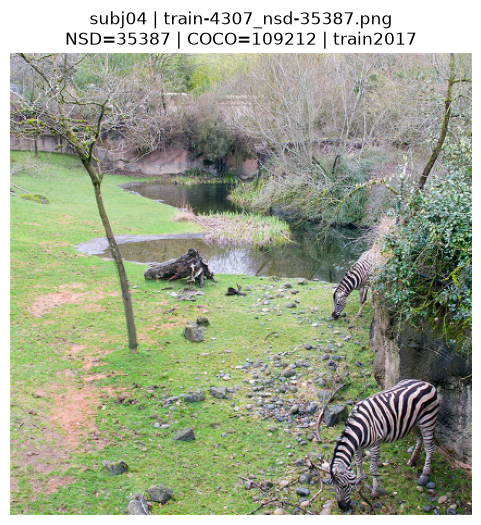

Captions:
  1. Two zebras graze next to a creek.
  2. A couple of zebra's eating grass by some water.
  3. Zebras graze on grass in front of a stream.
  4. A couple of zebras graze in their zoo habitat.
  5. This is a image of an zoo outdoor.


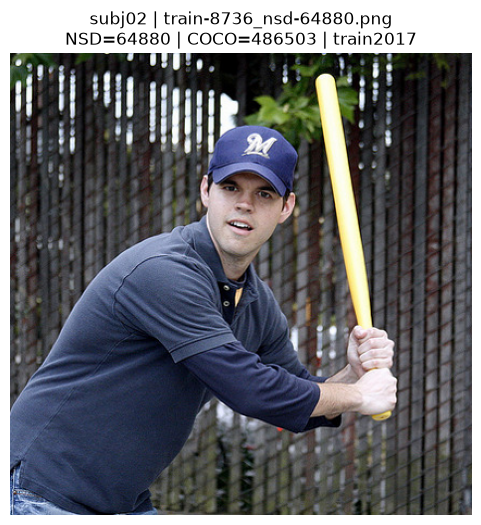

Captions:
  1. the man is wearing a blue hat with an M on it
  2. A man holding a bat next to a bamboo fence.
  3. A man is holding a wood baseball bat.
  4. A young man poses with a ball bat.
  5. A man taking a swing at a baseball


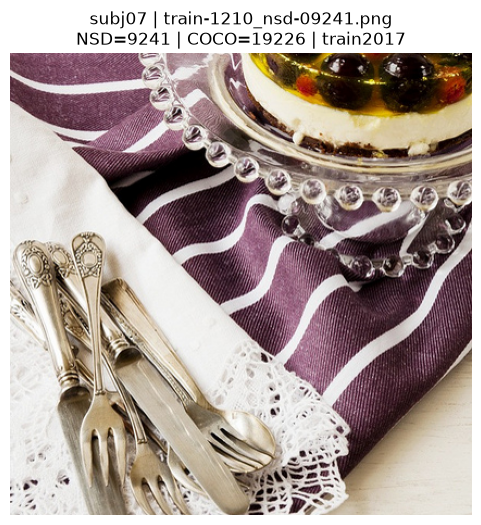

Captions:
  1. A table topped with a cake and eating utensils.
  2. some forks and knifes are laying near some food
  3. a desert on a purple fabric with silverware
  4. A dessert sits on a plate next to silver ware
  5. A cake with gelatin in it next to some silverware.


In [15]:
def show_samples(table: pd.DataFrame, n=3, seed=42):
    if table.empty:
        print("Tabla vacía")
        return

    sample = table.sample(
        n=min(n, len(table)),
        random_state=seed,
    )

    for _, row in sample.iterrows():
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f'{row["subject"]} | {row["filename"]}\n'
            f'NSD={row["nsd_id"]} | '
            f'COCO={row["coco_id"]} | '
            f'{row["coco_split"]}'
        )
        plt.show()

        print("Captions:")

        for i in range(1, 6):
            cap = row.get(f"caption_{i}")

            if pd.notna(cap):
                print(f"  {i}. {cap}")

        print("=" * 100)


show_samples(train_table, n=3, seed=SEED)

## 14. Preparar captions para controles experimentales

Se añaden:

- `primary_caption`: primer caption, fijo y reproducible;
- `sampled_caption_seed42`: uno de los captions humanos elegido de forma reproducible;
- `permuted_caption_seed42`: caption de otra imagen del mismo sujeto/split.

El caption permutado es útil como control negativo para comparar:

```text
fMRI_i + caption_i
vs.
fMRI_i + caption_j
```

In [16]:
def add_sampled_caption(table, seed=42):
    out = table.copy()

    if out.empty:
        out[f"sampled_caption_seed{seed}"] = pd.Series(dtype=object)
        return out

    local_rng = random.Random(seed)
    values = []

    for captions in out["captions"]:
        values.append(
            local_rng.choice(captions)
            if captions
            else None
        )

    out[f"sampled_caption_seed{seed}"] = values
    return out


def derangement(n, rng):
    if n <= 1:
        return np.arange(n)

    original = np.arange(n)

    for _ in range(10000):
        perm = rng.permutation(n)

        if np.all(perm != original):
            return perm

    return np.roll(original, 1)


def add_permuted_caption(table, seed=42):
    out = table.copy()

    caption_col = f"permuted_caption_seed{seed}"
    source_col = f"permuted_from_nsd_id_seed{seed}"

    out[caption_col] = None
    out[source_col] = np.nan

    if out.empty:
        return out

    local_rng = np.random.default_rng(seed)

    for (_, _), indices in out.groupby(
        ["split", "subject"]
    ).groups.items():

        indices = np.array(list(indices))

        if len(indices) <= 1:
            continue

        perm = derangement(
            len(indices),
            local_rng,
        )

        source_indices = indices[perm]

        out.loc[indices, caption_col] = (
            out.loc[source_indices, "primary_caption"]
            .to_numpy()
        )

        out.loc[indices, source_col] = (
            out.loc[source_indices, "nsd_id"]
            .to_numpy()
        )

    return out


train_table = add_sampled_caption(
    train_table,
    SEED,
)
train_table = add_permuted_caption(
    train_table,
    SEED,
)

test_table = add_sampled_caption(
    test_table,
    SEED,
)
test_table = add_permuted_caption(
    test_table,
    SEED,
)

display(
    train_table[
        [
            "subject",
            "filename",
            "primary_caption",
            f"sampled_caption_seed{SEED}",
            f"permuted_caption_seed{SEED}",
        ]
    ].head()
)

,subject,filename,primary_caption,sampled_caption_seed42,permuted_caption_seed42
0,subj01,train-0001_nsd-00013.png,A disorderly living area is free from decorative elements.,A disorderly living area is free from decorative elements.,Several motorcycles are displayed in a show room.
1,subj01,train-0002_nsd-00027.png,A row of doughnuts being passed through a fryer.,A row of doughnuts being passed through a fryer.,Looking up at a stop sign and street signs against a bright cloudy sky.
2,subj01,train-0003_nsd-00071.png,Various dishes of food sit in bowls on a table.,four different pictures of a variety of foods,A skateboard that is sitting in the snow.
3,subj01,train-0004_nsd-00085.png,A man surfing beside a bird on a cloudy day,A man that is on a surfboard in the water.,"A square glazed doughnut, and a chocolate doughnut on plates."
4,subj01,train-0005_nsd-00088.png,A small red bird perched by a wooden flower box,a red and black bird perched on a rail,A train traveling down a track past another train.


## 15. Guardar CSV y JSON

Se crean archivos globales y por sujeto.

Ejemplos:

```text
generated_captions/
├── algonauts_train_captions_all_subjects.csv
├── algonauts_train_captions_all_subjects.json
├── algonauts_test_captions_all_subjects.csv
├── subj01_train_captions.csv
├── subj01_train_captions.json
└── ...
```

In [17]:
def table_for_csv(table):
    out = table.copy()

    if "captions" in out.columns:
        out = out.drop(columns=["captions"])

    if "categories" in out.columns:
        out["categories"] = out["categories"].apply(
            lambda x: json.dumps(x, ensure_ascii=False)
            if isinstance(x, list)
            else x
        )

    return out


def json_safe_value(value):
    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return (
            None
            if np.isnan(value)
            else float(value)
        )

    if isinstance(value, float) and np.isnan(value):
        return None

    return value


def records_for_json(table):
    result = []

    for _, row in table.iterrows():
        record = {}

        for key, value in row.items():
            if isinstance(value, list):
                record[key] = [
                    json_safe_value(x)
                    for x in value
                ]
            else:
                record[key] = json_safe_value(value)

        result.append(record)

    return result


def save_table(table, stem):
    csv_path = OUTPUT_DIR / f"{stem}.csv"
    json_path = OUTPUT_DIR / f"{stem}.json"

    table_for_csv(table).to_csv(
        csv_path,
        index=False,
        encoding="utf-8",
    )

    with open(
        json_path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            records_for_json(table),
            f,
            ensure_ascii=False,
            indent=2,
        )

    return [csv_path, json_path]


saved = []

if len(train_table):
    saved += save_table(
        train_table,
        "algonauts_train_captions_all_subjects",
    )

if len(test_table):
    saved += save_table(
        test_table,
        "algonauts_test_captions_all_subjects",
    )

tables_to_concat = [
    x for x in [train_table, test_table]
    if len(x)
]

combined_table = pd.concat(
    tables_to_concat,
    ignore_index=True,
)

saved += save_table(
    combined_table,
    "algonauts_captions_all_subjects",
)

for table, split in [
    (train_table, "train"),
    (test_table, "test"),
]:
    if table.empty:
        continue

    for subject, group in table.groupby("subject"):
        group = (
            group
            .sort_values("challenge_idx_1based")
            .reset_index(drop=True)
        )

        saved += save_table(
            group,
            f"{subject}_{split}_captions",
        )

print("Archivos creados:")

for path in saved:
    print(" -", path)

Archivos creados:
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_train_captions_all_subjects.csv
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_train_captions_all_subjects.json
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_test_captions_all_subjects.csv
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_test_captions_all_subjects.json
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_captions_all_subjects.csv
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\algonauts_captions_all_subjects.json
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\subj01_train_captions.csv
 - C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\subj01_train_captions.json
 - C:\Users\xxdi

## 16. Resumen de cobertura

Útil para verificar y documentar cuántas muestras se han enlazado correctamente.

In [18]:
summary = (
    combined_table
    .groupby(["split", "subject"])
    .agg(
        n_images=("filename", "size"),
        n_unique_nsd=("nsd_id", "nunique"),
        n_unique_coco=("coco_id", "nunique"),
        min_captions=("num_captions", "min"),
        max_captions=("num_captions", "max"),
        missing_primary=(
            "primary_caption",
            lambda s: int(s.isna().sum()),
        ),
    )
    .reset_index()
)

display(summary)

summary_path = (
    OUTPUT_DIR
    / "caption_mapping_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8",
)

print("Resumen:", summary_path)

,split,subject,n_images,n_unique_nsd,n_unique_coco,min_captions,max_captions,missing_primary
0,test,subj01,159,159,159,5,5,0
1,test,subj02,159,159,159,5,5,0
2,test,subj03,293,293,293,5,6,0
3,test,subj04,395,395,395,5,5,0
4,test,subj05,159,159,159,5,5,0
5,test,subj06,293,293,293,5,6,0
6,test,subj07,159,159,159,5,5,0
7,test,subj08,395,395,395,5,5,0
8,train,subj01,9841,9841,9841,5,6,0
9,train,subj02,9841,9841,9841,5,6,0


Resumen: C:\Users\xxdia\Documents\Datasets\NSD_Algonauts_2023\auxiliar\generated_captions\caption_mapping_summary.csv


# 17. Integración opcional con PyTorch

Para `train`, la columna:

```text
row_idx_0based
```

se utiliza directamente como:

```python
lh_training_fmri[row_idx_0based]
rh_training_fmri[row_idx_0based]
```

El ejemplo siguiente concatena ambos hemisferios y devuelve además imagen y caption.

In [19]:
# OPCIONAL: descomenta si lo quieres integrar directamente en PyTorch.

# import torch
# from torch.utils.data import Dataset
#
#
# class AlgonautsFMRICaptionDataset(Dataset):
#     def __init__(
#         self,
#         captions_csv,
#         lh_fmri_path,
#         rh_fmri_path,
#         caption_mode="primary",
#         image_transform=None,
#         seed=42,
#     ):
#         self.df = (
#             pd.read_csv(captions_csv)
#             .sort_values("row_idx_0based")
#             .reset_index(drop=True)
#         )
#
#         self.lh = np.load(
#             lh_fmri_path,
#             mmap_mode="r",
#         )
#         self.rh = np.load(
#             rh_fmri_path,
#             mmap_mode="r",
#         )
#
#         if not (
#             len(self.df)
#             == self.lh.shape[0]
#             == self.rh.shape[0]
#         ):
#             raise ValueError(
#                 "El nº de captions/imágenes no coincide con el fMRI."
#             )
#
#         self.caption_mode = caption_mode
#         self.image_transform = image_transform
#         self.rng = random.Random(seed)
#
#
#     def __len__(self):
#         return len(self.df)
#
#
#     def _caption(self, row):
#         captions = [
#             row[f"caption_{i}"]
#             for i in range(1, 6)
#             if pd.notna(row.get(f"caption_{i}"))
#         ]
#
#         if self.caption_mode == "primary":
#             return row["primary_caption"]
#
#         if self.caption_mode == "random":
#             return self.rng.choice(captions)
#
#         if self.caption_mode == "permuted":
#             return row[f"permuted_caption_seed{SEED}"]
#
#         raise ValueError(
#             "caption_mode debe ser primary, random o permuted"
#         )
#
#
#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         fmri_idx = int(row["row_idx_0based"])
#
#         fmri = np.concatenate(
#             [
#                 np.asarray(
#                     self.lh[fmri_idx],
#                     dtype=np.float32,
#                 ),
#                 np.asarray(
#                     self.rh[fmri_idx],
#                     dtype=np.float32,
#                 ),
#             ]
#         )
#
#         image = Image.open(
#             row["image_path"]
#         ).convert("RGB")
#
#         if self.image_transform is not None:
#             image = self.image_transform(image)
#
#         return {
#             "fmri": torch.from_numpy(fmri),
#             "image": image,
#             "caption": self._caption(row),
#             "nsd_id": int(row["nsd_id"]),
#             "coco_id": int(row["coco_id"]),
#             "filename": row["filename"],
#         }

# 18. Condiciones experimentales para tu TFM

Con las columnas generadas puedes montar directamente:

| Experimento | fMRI | Texto |
|---|---:|---:|
| `fmri_only` | real | vacío |
| `caption_only_oracle` | cero/ausente | `primary_caption` |
| `fmri_plus_oracle` | real | `primary_caption` |
| `fmri_plus_permuted_caption` | real | `permuted_caption_seed42` |

Interpretación:

### fMRI-only
Tu baseline brain-only.

### caption-only oracle
Mide cuánto puede reconstruir el generador con semántica textual perfecta sin señal cerebral.

### fMRI + oracle caption
Da al generador el fMRI y además una descripción humana de la imagen objetivo. Es un **upper bound/control oracle**, no una reconstrucción brain-only.

### fMRI + caption permutado
Comprueba si importa que el texto corresponda realmente a la misma imagen/fMRI o si basta con proporcionar cualquier prompt.

---

## Nota importante sobre el test oficial de Algonauts

El release oficial del challenge proporciona las imágenes del test pero no sus respuestas fMRI. Este notebook puede obtener captions para esas imágenes, pero no genera ni recupera el fMRI oculto.

Para una evaluación brain-only con fMRI disponible, tendrás que usar los datos de entrenamiento publicados y crear tu propio train/validation/test interno, si ese es tu esquema experimental.

---

## Resultado principal

Para un sujeto concreto tendrás, por ejemplo:

```text
.../auxiliar/generated_captions/subj01_train_captions.csv
```

Cada fila representa explícitamente:

```text
fila fMRI
↕
imagen Algonauts
↕
NSD ID
↕
COCO ID
↕
captions humanos
```

Esto deja preparado el dataset para añadir condicionamiento textual a Stable Diffusion o para crear los controles oracle/permutado.